1. [Tiered architecture](#Tiered-architecture)
2. [Django](#Django)
    1. [MVC](#MVC)
    2. [Coding style](#Coding-style)
    3. [Enviroment setup](#Enviroment-setup)
    3. [Project structure](#Project-structure)
    4. [Configuration](#Configuration)
    5. [Dependencies](#Dependencies)
    6. [URL dispatching](#URL-dispatching)

## Tiered architecture

* https://stackshare.io/instagram/instagram
* https://stackshare.io/disqus/disqus
* https://stackshare.io/pinterest/pinterest

Start point

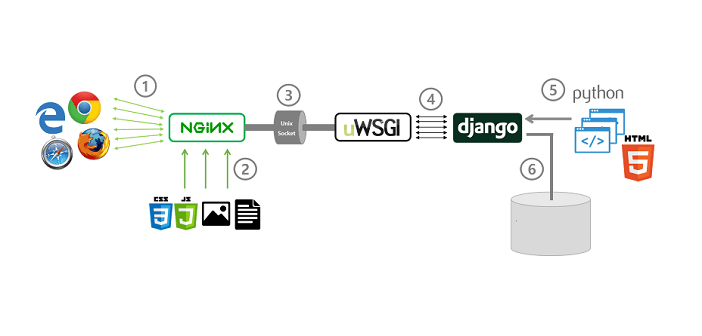

### References

* http://berb.github.io/diploma-thesis/original/033_archmodel.html
* https://www.insight-it.ru/highload/2012/arkhitektura-instagram/
* https://stackshare.io/stacks
* http://highload.guide/

### Summary

* Tiered acrchitecture is a current best practice

## Django

__Design philosophies__

* Loose coupling
* Less code
* Quick development
* DRY
* Explicit is better than implicit
* Consistency

#### MVC

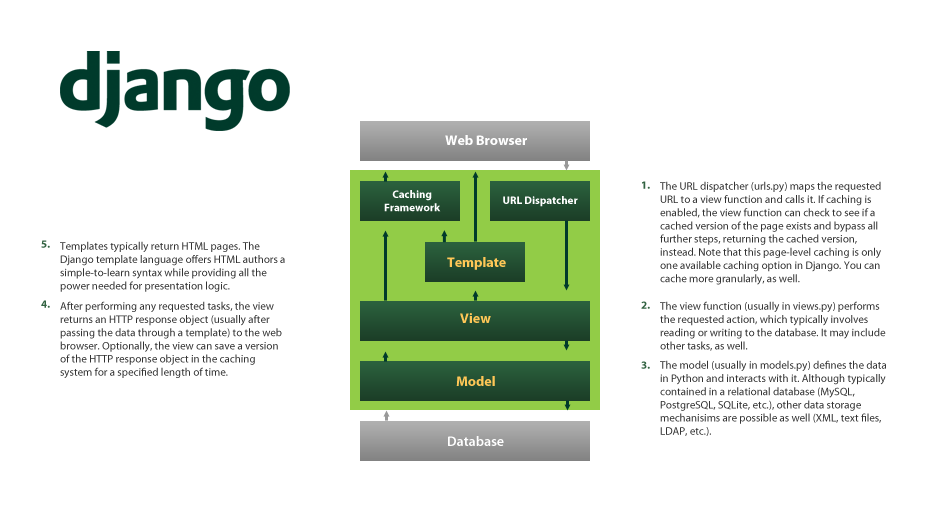

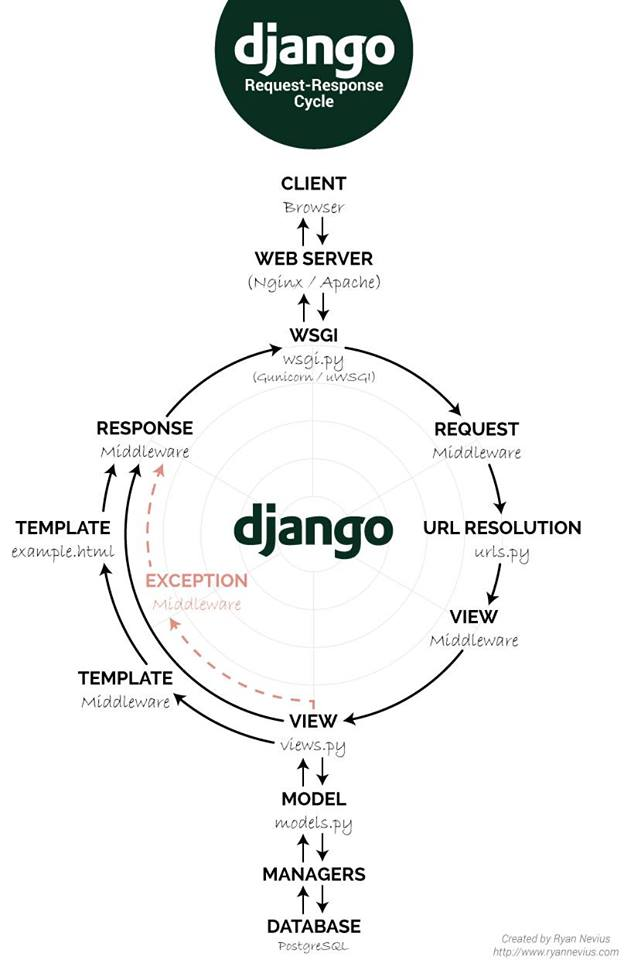

#### Coding style

* PEP8
    * Maximum line length
* Imports order
* Explicit relative imports

In [ ]:
from .models import Product
from .utils import hhh

In [ ]:
from models import Product

In [ ]:
from __future__ import unicode_literals

# Standard library imports
import json
from itertools import chain

# Third-party imports
import bcrypt

# Django imports
from django.http import (Http404, HttpResponse, HttpResponseNotAllowed,
                          StreamingHttpResponse)

# Local imports
from .models import Product, LogEntry
from .utils import hhh

# Try/except block
try:
    import yaml
except ImportError:
    yaml = None

CONSTANT = 'foo'

In [ ]:
# banners/views.py
from django.views.generic import CreateView

from .models import Banner
from .forms import BannerForm
from core.views import AdMixin

class BannerCreateView(AdMixin, CreateView):
    model = Banner
    form_class = BannerForm

Use underscore in URL pattern names

In [ ]:
from django.urls import path
from . import views

urlpatterns = [
    path('add/', views.add_banner, name='add_banner'),
]

In [ ]:
from django.urls import path, re_path
from . import views

urlpatterns = [
    # Без regex — предпочтительный вариант
    path('add/', views.add_banner, name="add_banner"),
    
    # С regex — если нужны регулярные выражения
    re_path(r'^add/$', views.add_banner, name="add_banner"),
]

#### Enviroment setup

* keep the gap between development and production small
    * example: dont use SQLite for dev and other DB for prod
* never rely on implicit existence of system-wide packages
    * declare all dependencies
    * use dependency isolation

In [ ]:
pip install virtualenvwrapper
export WORKON_HOME=~/Envs
source /usr/local/bin/virtualenvwrapper.sh


mkvirtualenv my_project
workon my_project

In [ ]:
1. create virtual env
linux/mac
source venv/bin/activate
win
.\venv\Scripts\activate



2. pip install django
pip install djangorestframework

3. django-admin startproject myproject
4. cd myproject http://127.0.0.1:8000
optional
1.pip freeze > requirements.txt

pip install -r requirements.txt

python manage.py runserver



#### Project structure

In [ ]:
django-admin startproject myproject 

In [ ]:
python manage.py startapp myapp

In [ ]:
myapp/
├── migrations/         # Миграции для этого приложения
│   └── __init__.py
├── __init__.py         # Пустой файл для обработки пакетов
├── admin.py            # Административная часть
├── apps.py             # Конфигурация приложения
├── models.py           # Модели, определяющие структуру данных
├── tests.py            # Тесты приложения
└── views.py            # Представления (функции или классы, обрабатывающие запросы)


In [ ]:
myproject/
├── manage.py
├── myproject/           # Основной проект
│   ├── __init__.py
│   ├── settings.py
│   ├── urls.py
│   ├── asgi.py
│   ├── wsgi.py
│   ├── middleware/      # Каталог для промежуточного ПО
│   └── templatetags/    # Кастомные теги шаблонов
│
└── apps/                # Каталог для всех приложений
    ├── __init__.py
    ├── users/           # Приложение для управления пользователями
    │   ├── __init__.py
    │   ├── models.py
    │   ├── views.py
    │   └── forms.py
    ├── blog/            # Приложение для блога
    │   ├── __init__.py
    │   ├── models.py
    │   ├── views.py
    │   └── urls.py
    └── orders/          # Приложение для заказов
        ├── __init__.py
        ├── models.py
        ├── views.py
        └── urls.py


#### Configuration

In [ ]:
settings.py

DATABASES = {
    'default': {
        'ENGINE': 'django.db.backends.postgresql',  # Драйвер для PostgreSQL
        'NAME': 'mydatabase',                      # Имя базы данных
        'USER': 'myuser',                          # Имя пользователя
        'PASSWORD': 'mypassword',                  # Пароль пользователя
        'HOST': 'localhost',                       # Хост базы данных
        'PORT': '5432',                            # Порт базы данных
    }
}


MIDDLEWARE = [
    'django.middleware.security.SecurityMiddleware',  # Обеспечивает безопасность приложения
    'django.contrib.sessions.middleware.SessionMiddleware',  # Управление сессиями
    'django.middleware.common.CommonMiddleware',      # Общая middleware для обработки ссылок
    'django.middleware.csrf.CsrfViewMiddleware',      # Защита от CSRF атак
    'django.contrib.auth.middleware.AuthenticationMiddleware',  # Аутентификация пользователя
    'django.contrib.messages.middleware.MessageMiddleware',  # Обработка сообщений
    'django.middleware.clickjacking.XFrameOptionsMiddleware',  # Защита от атак с помощью iframe
]

# Защита от CSRF атак
CSRF_COOKIE_SECURE = True
CSRF_COOKIE_HTTPONLY = True

# Настройки для cookies безопасности
SESSION_COOKIE_SECURE = True
SESSION_COOKIE_HTTPONLY = True

# Хэширование паролей
PASSWORD_HASHERS = [
    'django.contrib.auth.hashers.PBKDF2PasswordHasher',
    'django.contrib.auth.hashers.PBKDF2SHA1PasswordHasher',
]


STATIC_URL = '/static/'  # URL для доступа к статическим файлам

STATICFILES_DIRS = [
    BASE_DIR / 'static',  # Путь к дополнительным папкам с файлами
]

STATIC_ROOT = BASE_DIR / 'staticfiles'  # Папка для сбора всех статических файлов при деплое



In [ ]:
gunicorn myproject.wsgi:application --bind 0.0.0.0:8000


In [ ]:
pip install django-debug-toolbar

python manage.py migrate

In [ ]:
export DJANGO_SETTINGS_MODULE=mysite.settings
django-admin runserver

DJANGO_SETTINGS_MODULE=mysite.settings django-admin runserver

django-admin runserver --settings=mysite.settings

__Secrets__

In [ ]:
# settings/base.py
import os

# Normally you should not import ANYTHING from Django directly
# into your settings, but ImproperlyConfigured is an exception.
from django.core.exceptions import ImproperlyConfigured

def get_env_variable(var_name):
    """Get the environment variable or return exception."""
    try:
        return os.environ[var_name]
    except KeyError:
        error_msg = 'Set the {} environment variable'.format(var_name)
        raise ImproperlyConfigured(error_msg)


In [ ]:
# Top of settings/production.py
import os
SOME_SECRET_KEY = get_env_variable('SOME_SECRET_KEY')

In [ ]:
# settings/base.py
import json

from django.core.exceptions import ImproperlyConfigured

# JSON-based secrets module
with open('secrets.json') as f:
    secrets = json.loads(f.read())

def get_secret(setting, secrets=secrets):
    '''Get the secret variable or return explicit exception.'''
    try:
        return secrets[setting]
    except KeyError:
        error_msg = 'Set the {0} environment variable'.format(setting)
        raise ImproperlyConfigured(error_msg)

SECRET_KEY = get_secret('SECRET_KEY')

In [ ]:
pip install python-decouple

.env


In [ ]:
settings.py

from decouple import config

# Получаем SECRET_KEY и DEBUG из переменных окружения
SECRET_KEY = config('SECRET_KEY')
DEBUG = config('DEBUG', default=False, cast=bool)

# Для подключения к базе данных можно использовать DATABASE_URL
import dj_database_url
DATABASES = {
    'default': dj_database_url.config(default=config('DATABASE_URL'))
}

ALLOWED_HOSTS = config('ALLOWED_HOSTS', cast=lambda v: v.split(','))


In [ ]:
import os

SECRET_KEY = os.getenv('SECRET_KEY', 'defaultsecretkey')  # Используем значение по умолчанию на случай отсутствия переменной
DEBUG = os.getenv('DEBUG', 'False') == 'True'

# Доступ к базе данных
DATABASES = {
    'default': {
        'ENGINE': 'django.db.backends.postgresql',
        'NAME': os.getenv('DB_NAME'),
        'USER': os.getenv('DB_USER'),
        'PASSWORD': os.getenv('DB_PASSWORD'),
        'HOST': os.getenv('DB_HOST'),
        'PORT': os.getenv('DB_PORT', '5432'),
    }
}


__Paths__

In [ ]:
# myproject/urls.py
from django.contrib import admin
from django.urls import path, include

urlpatterns = [
    path('admin/', admin.site.urls),
    path('blog/', include('blog.urls')),  # Включаем URL-ы приложения "blog"
]


In [ ]:
# blog/urls.py
path('post/<int:id>/', views.detail, name='detail')


#### Dependencies

In [ ]:
pip freeze > requirements.txt


In [ ]:
pip install -r requirements/local.txt

In [ ]:
pip install pipenv
pipenv install django
pipenv install --dev


In [ ]:
pip install poetry
poetry init
poetry add django


#### URL dispatching

* Django determines the root URLconf module to use. Ordinarily, this is the value of the ROOT_URLCONF setting
* Django loads that Python module and looks for the variable urlpatterns.
* Django runs through each URL pattern, in order, and stops at the first one that matches the requested URL.
* Once one of the regexes matches, Django imports and calls the given view, which is a simple Python function (or a class-based view). The view gets passed the following arguments:
    * An instance of HttpRequest.
    * If the matched regular expression returned no named groups, then the matches from the regular expression are provided as positional arguments.
    * The keyword arguments are made up of any named groups matched by the regular expression, overridden by any arguments specified in the optional kwargs argument to django.conf.urls.url().
* If no regex matches, or if an exception is raised during any point in this process, Django invokes an appropriate error-handling view. 

In [ ]:
1.URLConf 

In [ ]:
from django.urls import path
from . import views

urlpatterns = [
    path('', views.index, name='index'),  # Главная страница
    path('about/', views.about, name='about'),  # Страница "О нас"
    path('contact/', views.contact, name='contact'),  # Страница "Контакты"
]


In [ ]:
2. Url-template

In [ ]:
from django.urls import path
from . import views

urlpatterns = [
    path('article/<int:id>/', views.article, name='article'),
]


In [ ]:
3. Views

In [ ]:
from django.http import HttpResponse

def article(request, id):
    return HttpResponse(f'Article ID: {id}')


In [ ]:
4.reex in urls

In [ ]:
from django.urls import re_path
from . import views

urlpatterns = [
    re_path(r'^article/(?P<id>\d+)/$', views.article, name='article'),
]


In [ ]:
5.url-names

In [ ]:
from django.urls import reverse

# Генерация URL для статьи с id = 123
url = reverse('article', kwargs={'id': 123})


In [ ]:
<a href="{% url 'article' id=123 %}">Article 123</a>


In [ ]:
6.url include

In [ ]:
# urls.py в основном проекте
from django.urls import path, include

urlpatterns = [
    path('blog/', include('blog.urls')),  # Включаем URLs из приложения blog
]


In [ ]:
# blog/urls.py
from django.urls import path
from . import views

urlpatterns = [
    path('', views.index, name='blog_index'),
    path('<int:id>/', views.article, name='blog_article'),
]


In [ ]:
7.CBV

In [ ]:
from django.http import HttpResponse
from django.views import View

class ArticleView(View):
    def get(self, request, id):
        return HttpResponse(f'Article ID: {id}')


In [ ]:
from django.urls import path
from .views import ArticleView

urlpatterns = [
    path('article/<int:id>/', ArticleView.as_view(), name='article'),
]


In [ ]:
# project urls.py

from django.contrib import admin
from django.urls import path, include

urlpatterns = [
    path('author-polls/', include('polls.urls', namespace='author-polls')),
    path('publisher-polls/', include('polls.urls', namespace='publisher-polls')),
    path('admin/', admin.site.urls),
]

In [ ]:
# polls/urls.py

from django.urls import path

from . import views

app_name = 'polls'

urlpatterns = [
    path('', views.IndexView.as_view(), name='index'),
    path('<int:pk>/', views.DetailView.as_view(), name='detail'),
]

In [ ]:
conda create -n myenv python=3.10
conda activate myenv

pip install django
django-admin startproject myproject

cd myproject
python manage.py runserver


pip install psycopg2
pip install mysqlclient


python manage.py startapp myapp




In [ ]:
FBV
from django.shortcuts import render
from .models import Product

def product_list(request):
    product = Product.objects.all()
    return render(request, 'product.html', {'products': products})




In [ ]:
CBV
from django.views.generic import ListView
from .models import Product

class ProductListView(ListView):
    model = Product
    template_name= 'product.html' 
    context_object_name = "products"


In [ ]:
FBV + CBV

from django.urls import path
from .views import ProductListView, contact

urlpatterns = [
    path('', ProductListView.as_view(), name='product_list'), CBV
    path('contact/', contact, name="contact")   FBV
]



### References

* https://docs.djangoproject.com/en/4.2/misc/design-philosophies/
* https://docs.djangoproject.com/en/4.2/internals/contributing/writing-code/coding-style/
* https://docs.djangoproject.com/en/4.2/internals/
* https://www.python.org/dev/peps/pep-0328/
* https://12factor.net/
* http://cookiecutter-django.readthedocs.io/en/latest/developing-locally-docker.html
* http://www.eidel.io/2017/07/10/dockerizing-django-uwsgi-postgres/
* https://github.com/pydanny/cookiecutter-django
* https://docs.djangoproject.com/en/4.2/topics/http/urls/
* http://klen.github.io/py-frameworks-bench/
* https://pypi.org/project/pydjantic/

### Summary

* Django follows MVC pattern
* Isolate your enviroment
* Split config
* Use enviroment variables
* Freeze dependencies